In [22]:
# Cell 1 - Imports

import sys
import os
import importlib
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is in path
sys.path.append(os.path.abspath(".."))

import model.assumptions as assumptions_module
import model.policy as policy_module
import model.valuation as valuation

In [23]:
# Cell 2 - Define reload all function

def reload_all():
    importlib.reload(assumptions_module)
    importlib.reload(policy_module)
    importlib.reload(valuation)

In [24]:
# Cell 3 - Run reload all to ensure latest code is loaded

reload_all()

In [25]:
# Cell 4 - Define assumptions and policy

assumptions = assumptions_module.Assumptions(interest_rate=0.03)

policy = policy_module.Policy(
    age=40,
    term=10,
    sum_assured=100000,
    premium=1000
)

In [26]:
# Cell 5 - Run valuation

result = valuation.value_policy(policy, assumptions, return_breakdown=True)

In [27]:
# Cell 6 - build df

df = pd.DataFrame(result["breakdown"])
df

,t,age,discount_factor,expected_premium,expected_claim,net_cashflow,pv_premium,pv_claim,pv_net,cum_profit,cum_cashflow
0,0,40,1.000000,1000.000000,111.277046,888.722954,1000.000000,111.277046,888.722954,888.722954,888.722954
1,1,41,0.970874,998.887230,120.410846,878.476383,969.793427,116.903734,852.889692,1741.612646,1767.199337
2,2,42,0.942596,997.683121,130.282274,867.400847,940.412029,122.803539,817.608490,2559.221136,2634.600183
3,3,43,0.915142,996.380298,140.948805,855.431494,911.829120,128.988123,782.840997,3342.062132,3490.031677
4,4,44,0.888487,994.970810,152.472024,842.498787,884.018678,135.469418,748.549260,4090.611392,4332.530464
5,5,45,0.862609,993.446090,164.917859,828.528231,856.955324,142.259594,714.695730,4805.307122,5161.058695
6,6,46,0.837484,991.796911,178.356809,813.440103,830.614299,149.371019,681.243280,5486.550402,5974.498798
7,7,47,0.813092,990.013343,192.864168,797.149176,804.971446,156.816218,648.155228,6134.705630,6771.647973
8,8,48,0.789409,988.084702,208.520248,779.564453,780.003188,164.607810,615.395378,6750.101008,7551.212427
9,9,49,0.766417,985.999499,225.410588,760.588912,755.686514,172.758446,582.928068,7333.029077,8311.801338


In [28]:
# Cell 7 - Debugging

df[["t",
    "net_cashflow",
    "cum_cashflow",
    "pv_net",
    "cum_profit"]]

,t,net_cashflow,cum_cashflow,pv_net,cum_profit
0,0,888.722954,888.722954,888.722954,888.722954
1,1,878.476383,1767.199337,852.889692,1741.612646
2,2,867.400847,2634.600183,817.608490,2559.221136
3,3,855.431494,3490.031677,782.840997,3342.062132
4,4,842.498787,4332.530464,748.549260,4090.611392
5,5,828.528231,5161.058695,714.695730,4805.307122
6,6,813.440103,5974.498798,681.243280,5486.550402
7,7,797.149176,6771.647973,648.155228,6134.705630
8,8,779.564453,7551.212427,615.395378,6750.101008
9,9,760.588912,8311.801338,582.928068,7333.029077


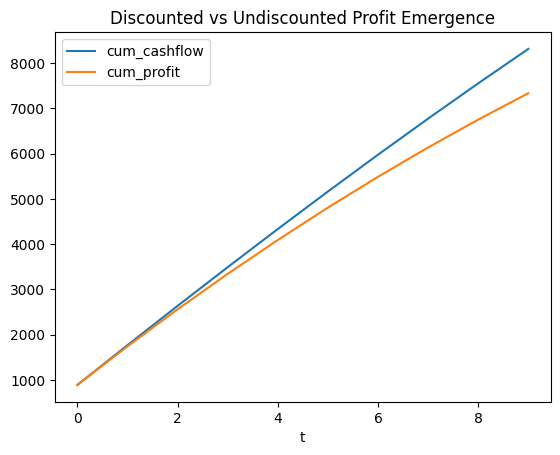

In [30]:
# Cell 8 - Define and print profit emergence plot

df.plot(x="t", y=["cum_cashflow", "cum_profit"])
plt.title("Discounted vs Undiscounted Profit Emergence")
plt.show()

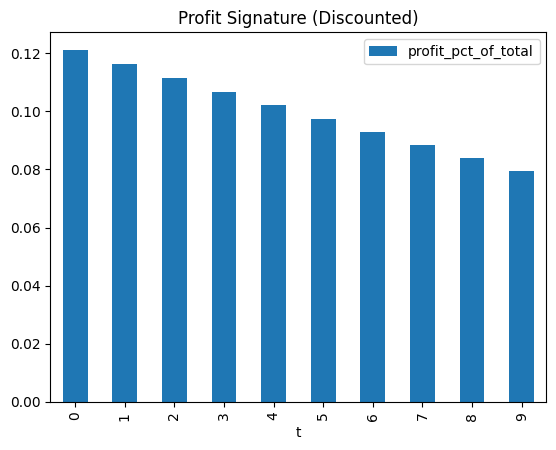

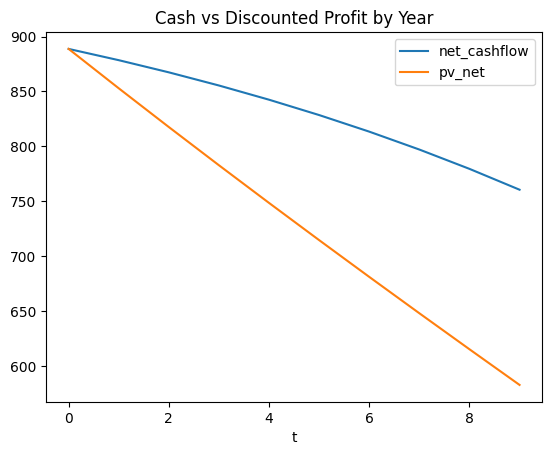

In [31]:
# Cell 9 Add simple analysis of profit signature

df["profit_change"] = df["pv_net"]
df["profit_pct_of_total"] = df["pv_net"] / df["pv_net"].sum()

df.plot(x="t", y="profit_pct_of_total", kind="bar")
plt.title("Profit Signature (Discounted)")
plt.show()

df.plot(x="t", y=["net_cashflow", "pv_net"])
plt.title("Cash vs Discounted Profit by Year")
plt.show()